In [1]:
import yfinance as yf
import pandas as pd

df = yf.download("^NSEI", start="2020-01-01", end="2024-12-31")

print("Total rows:", len(df))
print(df.head())

# Save to CSV
df.to_csv("nifty50_data.csv")
print("Data saved to nifty50_data.csv ✓")

[*********************100%***********************]  1 of 1 completed

Total rows: 1236
Price              Close          High           Low          Open  Volume
Ticker             ^NSEI         ^NSEI         ^NSEI         ^NSEI   ^NSEI
Date                                                                      
2020-01-01  12182.500000  12222.200195  12165.299805  12202.150391  304100
2020-01-02  12282.200195  12289.900391  12195.250000  12198.549805  407700
2020-01-03  12226.650391  12265.599609  12191.349609  12261.099609  428800
2020-01-06  11993.049805  12179.099609  11974.200195  12170.599609  396500
2020-01-07  12052.950195  12152.150391  12005.349609  12079.099609  447800
Data saved to nifty50_data.csv ✓


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Fix multi-header issue from yfinance CSV
df = pd.read_csv("nifty50_data.csv", index_col=0, header=[0,1])

# Flatten the multi-level columns
df.columns = df.columns.get_level_values(0)

# Drop the extra 'Ticker' and 'Date' rows
df = df.iloc[2:]

# Fix index to datetime
df.index = pd.to_datetime(df.index)

# Convert all columns to numeric
df = df.apply(pd.to_numeric, errors='coerce')

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Date range:", df.index.min(), "to", df.index.max())
df.head()

Shape: (1234, 5)
Columns: ['Close', 'High', 'Low', 'Open', 'Volume']
Date range: 2020-01-03 00:00:00 to 2024-12-30 00:00:00


Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-03,12226.650391,12265.599609,12191.349609,12261.099609,428800
2020-01-06,11993.049805,12179.099609,11974.200195,12170.599609,396500
2020-01-07,12052.950195,12152.150391,12005.349609,12079.099609,447800
2020-01-08,12025.349609,12044.950195,11929.599609,11939.099609,446000
2020-01-09,12215.900391,12224.049805,12132.549805,12153.150391,477500


In [4]:
print("Missing values:\n", df.isnull().sum())
print("\nBefore cleaning:", df.shape)
df = df.dropna()
df = df[~df.index.duplicated(keep='first')]
print("After cleaning:", df.shape)

Missing values:
 Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Before cleaning: (1234, 5)
After cleaning: (1234, 5)


In [5]:
df.describe().round(2)

Price,Close,High,Low,Open,Volume
count,1234.00,1234.00,1234.00,1234.00,1234.00
mean,17343.41,17437.92,17242.67,17354.50,386071.23
std,4185.85,4188.32,4183.79,4185.45,205912.35
min,7610.25,8036.95,7511.10,7735.15,0.00
25%,14865.25,14924.09,14717.40,14857.95,249600.00
50%,17523.77,17614.12,17405.40,17521.90,310500.00
75%,19651.64,19698.49,19553.26,19626.00,496950.00
max,26216.05,26277.35,26151.40,26248.25,1811000.00


In [6]:
df['Daily_Return'] = df['Close'].pct_change() * 100
df['Daily_Range'] = df['High'] - df['Low']
df['Cumulative_Return'] = (1 + df['Close'].pct_change()).cumprod()
df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['SMA_50'] = df['Close'].rolling(window=50).mean()

df[['Close', 'Daily_Return', 'Daily_Range', 'Cumulative_Return', 'SMA_20', 'SMA_50']].head(10)

Price,Close,Daily_Return,Daily_Range,Cumulative_Return,SMA_20,SMA_50
Date,,,,,,
2020-01-03,12226.650391,NaN,74.250000,NaN,NaN,NaN
2020-01-06,11993.049805,-1.910585,204.899414,0.980894,NaN,NaN
2020-01-07,12052.950195,0.499459,146.800781,0.985793,NaN,NaN
2020-01-08,12025.349609,-0.228994,115.350586,0.983536,NaN,NaN
2020-01-09,12215.900391,1.584576,91.500000,0.999121,NaN,NaN
2020-01-10,12256.799805,0.334805,98.000000,1.002466,NaN,NaN
2020-01-13,12329.549805,0.593548,51.950195,1.008416,NaN,NaN
2020-01-14,12362.299805,0.265622,65.549805,1.011095,NaN,NaN
2020-01-15,12343.299805,-0.153693,76.400391,1.009541,NaN,NaN


In [7]:
best_day = df['Daily_Return'].idxmax()
worst_day = df['Daily_Return'].idxmin()

print(f"Best day:  {best_day.date()} → {df.loc[best_day, 'Daily_Return']:.2f}%")
print(f"Worst day: {worst_day.date()} → {df.loc[worst_day, 'Daily_Return']:.2f}%")

up_days = (df['Daily_Return'] > 0).sum()
down_days = (df['Daily_Return'] < 0).sum()
print(f"\nUp days:   {up_days}")
print(f"Down days: {down_days}")

Best day:  2020-04-07 → 8.76%
Worst day: 2020-03-23 → -12.98%

Up days:   683
Down days: 549


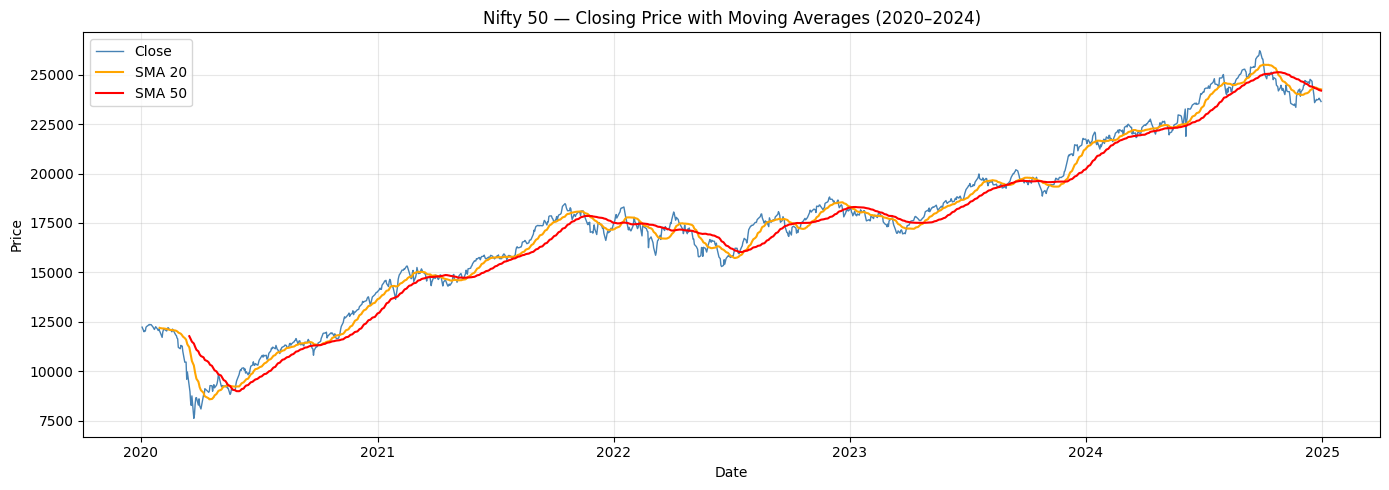

In [8]:
plt.figure(figsize=(14, 5))
plt.plot(df['Close'], label='Close', color='steelblue', linewidth=1)
plt.plot(df['SMA_20'], label='SMA 20', color='orange', linewidth=1.5)
plt.plot(df['SMA_50'], label='SMA 50', color='red', linewidth=1.5)
plt.title('Nifty 50 — Closing Price with Moving Averages (2020–2024)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
df.to_csv("nifty50_cleaned.csv")
print("Saved! ✓ Final shape:", df.shape)

Saved! ✓ Final shape: (1234, 10)


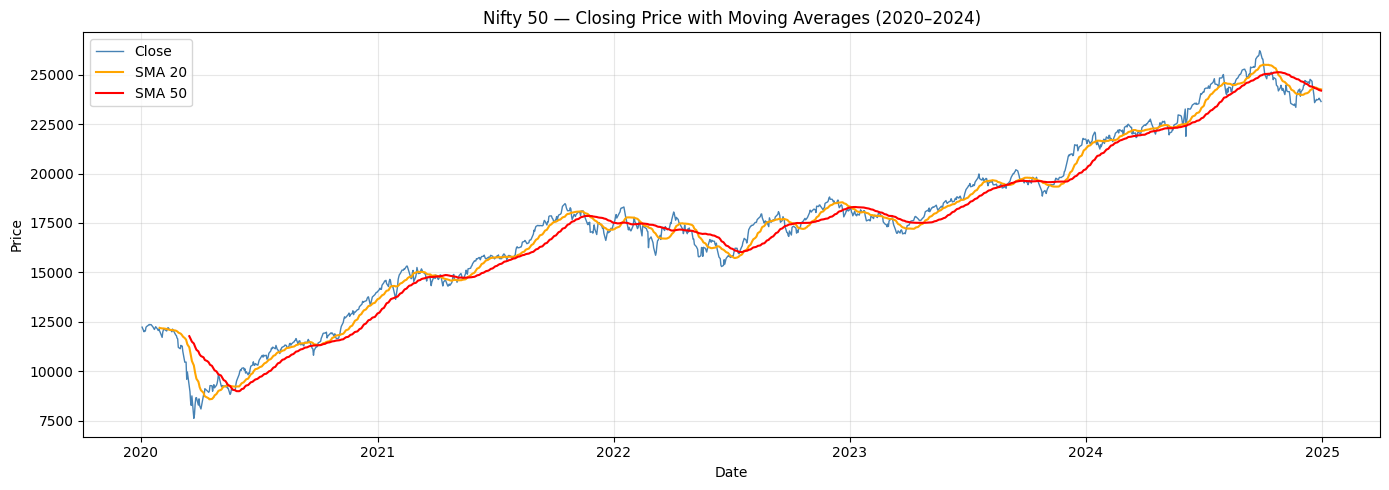

In [10]:
plt.figure(figsize=(14, 5))
plt.plot(df['Close'], label='Close', color='steelblue', linewidth=1)
plt.plot(df['SMA_20'], label='SMA 20', color='orange', linewidth=1.5)
plt.plot(df['SMA_50'], label='SMA 50', color='red', linewidth=1.5)
plt.title('Nifty 50 — Closing Price with Moving Averages (2020–2024)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("C:/Users/barku/nifty50_data.csv", index_col=0, parse_dates=True)
print("Shape:", df.shape)
df.head()

Shape: (1238, 5)


C:\Users\barku\AppData\Local\Temp\ipykernel_14232\485610277.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv("C:/Users/barku/nifty50_data.csv", index_col=0, parse_dates=True)


,Close,High,Low,Open,Volume
Price,,,,,
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
Date,NaN,NaN,NaN,NaN,NaN
2020-01-01,12182.5,12222.2001953125,12165.2998046875,12202.150390625,304100
2020-01-02,12282.2001953125,12289.900390625,12195.25,12198.5498046875,407700
2020-01-03,12226.650390625,12265.599609375,12191.349609375,12261.099609375,428800


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load and clean properly
df = pd.read_csv("C:/Users/barku/nifty50_data.csv", index_col=0, skiprows=[1,2], parse_dates=True)

# Convert all columns to numeric
df = df.apply(pd.to_numeric, errors='coerce')

# Drop any NaN rows created by conversion
df = df.dropna()

# Fix column names if needed
df.columns = df.columns.str.strip()

print("Shape:", df.shape)
print("Dtypes:\n", df.dtypes)
df.head()

Shape: (1236, 5)
Dtypes:
 Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object


,Close,High,Low,Open,Volume
Price,,,,,
2020-01-01,12182.500000,12222.200195,12165.299805,12202.150391,304100
2020-01-02,12282.200195,12289.900391,12195.250000,12198.549805,407700
2020-01-03,12226.650391,12265.599609,12191.349609,12261.099609,428800
2020-01-06,11993.049805,12179.099609,11974.200195,12170.599609,396500
2020-01-07,12052.950195,12152.150391,12005.349609,12079.099609,447800


In [13]:
# Confirm Close is numeric
print(type(df['Close'].iloc[0]))
print(df['Close'].head())

<class 'numpy.float64'>
Price
2020-01-01    12182.500000
2020-01-02    12282.200195
2020-01-03    12226.650391
2020-01-06    11993.049805
2020-01-07    12052.950195
Name: Close, dtype: float64


In [14]:
# Simple Moving Averages
df['SMA_20']  = df['Close'].rolling(window=20).mean()
df['SMA_50']  = df['Close'].rolling(window=50).mean()
df['SMA_200'] = df['Close'].rolling(window=200).mean()

# Exponential Moving Averages
df['EMA_20'] = df['Close'].ewm(span=20, adjust=False).mean()
df['EMA_50'] = df['Close'].ewm(span=50, adjust=False).mean()

print("Moving averages added ✓")
df[['Close', 'SMA_20', 'SMA_50', 'SMA_200', 'EMA_20', 'EMA_50']].head(10)

Moving averages added ✓


,Close,SMA_20,SMA_50,SMA_200,EMA_20,EMA_50
Price,,,,,,
2020-01-01,12182.500000,NaN,NaN,NaN,12182.500000,12182.500000
2020-01-02,12282.200195,NaN,NaN,NaN,12191.995257,12186.409812
2020-01-03,12226.650391,NaN,NaN,NaN,12195.295746,12187.987874
2020-01-06,11993.049805,NaN,NaN,NaN,12176.034227,12180.343243
2020-01-07,12052.950195,NaN,NaN,NaN,12164.311939,12175.347438
2020-01-08,12025.349609,NaN,NaN,NaN,12151.077431,12169.465170
2020-01-09,12215.900391,NaN,NaN,NaN,12157.251046,12171.286159
2020-01-10,12256.799805,NaN,NaN,NaN,12166.731880,12174.639635
2020-01-13,12329.549805,NaN,NaN,NaN,12182.238349,12180.714544


In [36]:
# Bollinger Bands (20-day, 2 standard deviations)
df['BB_Middle'] = df['Close'].rolling(window=20).mean()
df['BB_Std']    = df['Close'].rolling(window=20).std()
df['BB_Upper']  = df['BB_Middle'] + (2 * df['BB_Std'])
df['BB_Lower']  = df['BB_Middle'] - (2 * df['BB_Std'])
df['BB_Width']  = df['BB_Upper'] - df['BB_Lower']  # measures volatility

print("Bollinger Bands added ✓")
df[['Close', 'BB_Upper', 'BB_Middle', 'BB_Lower']].tail(10)

Bollinger Bands added ✓


,Close,BB_Upper,BB_Middle,BB_Lower
1175,24668.250000,25147.746977,24270.447754,23393.148531
1176,24336.000000,25103.204417,24314.557715,23525.911013
1177,24198.849609,25046.069040,24348.575195,23651.081351
1178,23951.699219,24931.726470,24378.665137,23825.603803
1179,23587.500000,24987.011053,24362.677637,23738.344220
1180,23753.449219,25018.555295,24339.255078,23659.954861
1181,23727.650391,25046.318478,24315.912598,23585.506717
1182,23750.199219,25062.733624,24289.677539,23516.621454
1183,23813.400391,25069.226605,24284.640039,23500.053473
1184,23644.900391,25093.568409,24260.330078,23427.091748


In [16]:
def calculate_rsi(series, period=14):
    delta = series.diff()
    gain  = delta.where(delta > 0, 0)
    loss  = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()
    rs  = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df['RSI_14'] = calculate_rsi(df['Close'], 14)

print("RSI added ✓")
print("Overbought days (RSI > 70):", (df['RSI_14'] > 70).sum())
print("Oversold days  (RSI < 30):", (df['RSI_14'] < 30).sum())

RSI added ✓
Overbought days (RSI > 70): 312
Oversold days  (RSI < 30): 75


In [17]:
# MACD = EMA12 - EMA26
df['MACD_Line']   = df['Close'].ewm(span=12, adjust=False).mean() - \
                    df['Close'].ewm(span=26, adjust=False).mean()
df['MACD_Signal'] = df['MACD_Line'].ewm(span=9, adjust=False).mean()
df['MACD_Hist']   = df['MACD_Line'] - df['MACD_Signal']

print("MACD added ✓")
df[['Close', 'MACD_Line', 'MACD_Signal', 'MACD_Hist']].tail(10)

MACD added ✓


,Close,MACD_Line,MACD_Signal,MACD_Hist
Price,,,,
2024-12-16,24668.250000,117.840176,50.881287,66.958889
2024-12-17,24336.000000,93.915188,59.488067,34.427121
2024-12-18,24198.849609,63.159508,60.222356,2.937153
2024-12-19,23951.699219,18.627711,51.903427,-33.275716
2024-12-20,23587.500000,-45.527084,32.417324,-77.944409
2024-12-23,23753.449219,-82.033872,9.527085,-91.560957
2024-12-24,23727.650391,-111.759223,-14.730176,-97.029046
2024-12-26,23750.199219,-131.975939,-38.179329,-93.796610
2024-12-27,23813.400391,-141.269558,-58.797375,-82.472184


In [18]:
# Returns
df['Daily_Return']      = df['Close'].pct_change() * 100
df['Cumulative_Return'] = (1 + df['Close'].pct_change()).cumprod()

# Volatility (rolling 30-day standard deviation of returns)
df['Volatility_30'] = df['Daily_Return'].rolling(window=30).std()

# Daily range
df['Daily_Range'] = df['High'] - df['Low']

print("Returns & Volatility added ✓")

Returns & Volatility added ✓


In [19]:
df['Year']        = df.index.year
df['Month']       = df.index.month
df['Month_Name']  = df.index.strftime('%B')
df['Quarter']     = df.index.quarter
df['Day_of_Week'] = df.index.day_name()
df['Week_Number'] = df.index.isocalendar().week.astype(int)

print("Date features added ✓")

Date features added ✓


In [20]:
# Trend signal based on SMA
df['Trend'] = np.where(df['Close'] > df['SMA_200'], 'Uptrend', 'Downtrend')

# RSI signal
df['RSI_Signal'] = np.where(df['RSI_14'] > 70, 'Overbought',
                   np.where(df['RSI_14'] < 30, 'Oversold', 'Neutral'))

# MACD signal
df['MACD_Signal_Flag'] = np.where(df['MACD_Hist'] > 0, 'Bullish', 'Bearish')

print("Signals added ✓")
print(df['Trend'].value_counts())
print(df['RSI_Signal'].value_counts())

Signals added ✓
Trend
Uptrend      921
Downtrend    315
Name: count, dtype: int64
RSI_Signal
Neutral       849
Overbought    312
Oversold       75
Name: count, dtype: int64


In [21]:
print("Final shape:", df.shape)
print("Total columns:", df.columns.tolist())

# Save final dataset
df.to_csv("nifty50_features.csv")
print("\nSaved as nifty50_features.csv ✓")

Final shape: (1236, 32)
Total columns: ['Close', 'High', 'Low', 'Open', 'Volume', 'SMA_20', 'SMA_50', 'SMA_200', 'EMA_20', 'EMA_50', 'BB_Middle', 'BB_Std', 'BB_Upper', 'BB_Lower', 'BB_Width', 'RSI_14', 'MACD_Line', 'MACD_Signal', 'MACD_Hist', 'Daily_Return', 'Cumulative_Return', 'Volatility_30', 'Daily_Range', 'Year', 'Month', 'Month_Name', 'Quarter', 'Day_of_Week', 'Week_Number', 'Trend', 'RSI_Signal', 'MACD_Signal_Flag']

Saved as nifty50_features.csv ✓


In [22]:
pip install mysql-connector-python sqlalchemy

Note: you may need to restart the kernel to use updated packages.


In [23]:
from sqlalchemy import create_engine
import pandas as pd


# Step 1: Connect to MySQL

username = "project"          # your MySQL username
password = "hbb8983711915"    # your MySQL password
host = "127.0.0.1"            # local server
port = "3306"                 # MySQL default port
database = "nifty50_db"  # your database name

engine = create_engine(f"mysql+mysqlconnector://{username}:{password}@{host}:{port}/{database}")

# Step 2: Load DataFrame into MySQL

table_name = "nifty50"   # table name you want to create

df.to_sql(table_name, engine, if_exists="replace", index=False)

print(f"Data successfully loaded into table '{table_name}' in database '{database}'.")

Data successfully loaded into table 'nifty50' in database 'nifty50_db'.


In [24]:
df.isnull().sum()

Close                  0
High                   0
Low                    0
Open                   0
Volume                 0
SMA_20                19
SMA_50                49
SMA_200              199
EMA_20                 0
EMA_50                 0
BB_Middle             19
BB_Std                19
BB_Upper              19
BB_Lower              19
BB_Width              19
RSI_14                13
MACD_Line              0
MACD_Signal            0
MACD_Hist              0
Daily_Return           1
Cumulative_Return      1
Volatility_30         30
Daily_Range            0
Year                   0
Month                  0
Month_Name             0
Quarter                0
Day_of_Week            0
Week_Number            0
Trend                  0
RSI_Signal             0
MACD_Signal_Flag       0
dtype: int64

In [25]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine

# Reload the features CSV
df = pd.read_csv("nifty50_features.csv")

# Check what columns we have
print(df.columns.tolist())
print(df.head(2))

['Price', 'Close', 'High', 'Low', 'Open', 'Volume', 'SMA_20', 'SMA_50', 'SMA_200', 'EMA_20', 'EMA_50', 'BB_Middle', 'BB_Std', 'BB_Upper', 'BB_Lower', 'BB_Width', 'RSI_14', 'MACD_Line', 'MACD_Signal', 'MACD_Hist', 'Daily_Return', 'Cumulative_Return', 'Volatility_30', 'Daily_Range', 'Year', 'Month', 'Month_Name', 'Quarter', 'Day_of_Week', 'Week_Number', 'Trend', 'RSI_Signal', 'MACD_Signal_Flag']
        Price         Close          High           Low          Open  Volume  \
0  2020-01-01  12182.500000  12222.200195  12165.299805  12202.150391  304100   
1  2020-01-02  12282.200195  12289.900391  12195.250000  12198.549805  407700   

   SMA_20  SMA_50  SMA_200        EMA_20  ...  Daily_Range  Year  Month  \
0     NaN     NaN      NaN  12182.500000  ...    56.900391  2020      1   
1     NaN     NaN      NaN  12191.995257  ...    94.650391  2020      1   

   Month_Name  Quarter  Day_of_Week  Week_Number      Trend  RSI_Signal  \
0     January        1    Wednesday            1  Downtren

In [26]:
# Reset index to bring date back as a column
df = pd.read_csv("nifty50_features.csv", index_col=0, parse_dates=True)
df.index.name = 'Trade_Date'
df.reset_index(inplace=True)

# Convert numeric columns
cols = df.columns.drop('Trade_Date')
df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')

print("Columns:", df.columns.tolist())
print("Shape:", df.shape)
df.head(3)

Columns: ['Trade_Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'SMA_20', 'SMA_50', 'SMA_200', 'EMA_20', 'EMA_50', 'BB_Middle', 'BB_Std', 'BB_Upper', 'BB_Lower', 'BB_Width', 'RSI_14', 'MACD_Line', 'MACD_Signal', 'MACD_Hist', 'Daily_Return', 'Cumulative_Return', 'Volatility_30', 'Daily_Range', 'Year', 'Month', 'Month_Name', 'Quarter', 'Day_of_Week', 'Week_Number', 'Trend', 'RSI_Signal', 'MACD_Signal_Flag']
Shape: (1236, 33)


,Trade_Date,Close,High,Low,Open,Volume,SMA_20,SMA_50,SMA_200,EMA_20,...,Daily_Range,Year,Month,Month_Name,Quarter,Day_of_Week,Week_Number,Trend,RSI_Signal,MACD_Signal_Flag
0,2020-01-01,12182.500000,12222.200195,12165.299805,12202.150391,304100,NaN,NaN,NaN,12182.500000,...,56.900391,2020,1,NaN,1,NaN,1,NaN,NaN,NaN
1,2020-01-02,12282.200195,12289.900391,12195.250000,12198.549805,407700,NaN,NaN,NaN,12191.995257,...,94.650391,2020,1,NaN,1,NaN,1,NaN,NaN,NaN
2,2020-01-03,12226.650391,12265.599609,12191.349609,12261.099609,428800,NaN,NaN,NaN,12195.295746,...,74.250000,2020,1,NaN,1,NaN,1,NaN,NaN,NaN


In [27]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine

# Load cleaned data
df = pd.read_csv("C:/Users/barku/OneDrive/Desktop/Nefity50/nifty50_cleaned.csv", index_col=0, skiprows=[1,2], parse_dates=True)
df = df.apply(pd.to_numeric, errors='coerce')
df = df.dropna()
df.index.name = 'Trade_Date'
df.reset_index(inplace=True)

print("Shape:", df.shape)
print(df.dtypes)
df.head(3)

Shape: (1185, 11)
Trade_Date           datetime64[us]
Close                       float64
High                        float64
Low                         float64
Open                        float64
Volume                        int64
Daily_Return                float64
Daily_Range                 float64
Cumulative_Return           float64
SMA_20                      float64
SMA_50                      float64
dtype: object


,Trade_Date,Close,High,Low,Open,Volume,Daily_Return,Daily_Range,Cumulative_Return,SMA_20,SMA_50
0,2020-03-16,9197.400391,9602.200195,9165.099609,9587.799805,897700,-7.612100,437.100586,0.752242,11204.872607,11767.430039
1,2020-03-17,8967.049805,9403.799805,8915.599609,9285.400391,935600,-2.504518,488.200195,0.733402,11047.552588,11702.238027
2,2020-03-18,8468.799805,9127.549805,8407.049805,9088.450195,1516600,-5.556454,720.500000,0.692651,10868.702588,11631.753027


In [28]:
df = df.sort_values('Trade_Date').reset_index(drop=True)

# Moving averages
df['SMA_20']  = df['Close'].rolling(window=20).mean()
df['SMA_50']  = df['Close'].rolling(window=50).mean()
df['SMA_200'] = df['Close'].rolling(window=200).mean()
df['EMA_20']  = df['Close'].ewm(span=20, adjust=False).mean()
df['EMA_50']  = df['Close'].ewm(span=50, adjust=False).mean()

# Bollinger Bands
df['BB_Middle'] = df['Close'].rolling(window=20).mean()
df['BB_Std']    = df['Close'].rolling(window=20).std()
df['BB_Upper']  = df['BB_Middle'] + (2 * df['BB_Std'])
df['BB_Lower']  = df['BB_Middle'] - (2 * df['BB_Std'])
df['BB_Width']  = df['BB_Upper'] - df['BB_Lower']

# RSI
def calculate_rsi(series, period=14):
    delta    = series.diff()
    gain     = delta.where(delta > 0, 0)
    loss     = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()
    rs       = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

df['RSI_14'] = calculate_rsi(df['Close'], 14)

# MACD
df['MACD_Line']   = df['Close'].ewm(span=12, adjust=False).mean() - \
                    df['Close'].ewm(span=26, adjust=False).mean()
df['MACD_Signal'] = df['MACD_Line'].ewm(span=9, adjust=False).mean()
df['MACD_Hist']   = df['MACD_Line'] - df['MACD_Signal']

# Returns & Volatility
df['Daily_Return']      = df['Close'].pct_change() * 100
df['Cumulative_Return'] = (1 + df['Close'].pct_change()).cumprod()
df['Volatility_30']     = df['Daily_Return'].rolling(window=30).std()
df['Daily_Range']       = df['High'] - df['Low']

# Date features — directly from Trade_Date column
df['Year']        = pd.to_datetime(df['Trade_Date']).dt.year
df['Month']       = pd.to_datetime(df['Trade_Date']).dt.month
df['Month_Name']  = pd.to_datetime(df['Trade_Date']).dt.strftime('%B')
df['Quarter']     = pd.to_datetime(df['Trade_Date']).dt.quarter
df['Day_of_Week'] = pd.to_datetime(df['Trade_Date']).dt.day_name()
df['Week_Number'] = pd.to_datetime(df['Trade_Date']).dt.isocalendar().week.astype(int)

# Signals
df['Trend']            = np.where(df['Close'] > df['SMA_200'], 'Uptrend', 'Downtrend')
df['RSI_Signal']       = np.where(df['RSI_14'] > 70, 'Overbought',
                         np.where(df['RSI_14'] < 30, 'Oversold', 'Neutral'))
df['MACD_Signal_Flag'] = np.where(df['MACD_Hist'] > 0, 'Bullish', 'Bearish')

print("All features added ✓")
print("Shape:", df.shape)
print("\nSample Trend values:", df['Trend'].value_counts())
print("Sample Month values:", df['Month'].value_counts().sort_index())

All features added ✓
Shape: (1185, 33)

Sample Trend values: Trend
Uptrend      870
Downtrend    315
Name: count, dtype: int64
Sample Month values: Month
1      82
2      81
3      93
4      93
5     103
6     106
7     108
8     105
9     106
10    102
11     99
12    107
Name: count, dtype: int64


In [29]:
# Quick check — no nulls in key columns
print("Nulls in key columns:")
print(df[['Trade_Date','Close','Trend','Month','RSI_Signal']].isnull().sum())

# Preview
df[['Trade_Date','Close','Trend','Month','Month_Name','RSI_Signal','MACD_Signal_Flag']].head(10)

Nulls in key columns:
Trade_Date    0
Close         0
Trend         0
Month         0
RSI_Signal    0
dtype: int64


,Trade_Date,Close,Trend,Month,Month_Name,RSI_Signal,MACD_Signal_Flag
0,2020-03-16,9197.400391,Downtrend,3,March,Neutral,Bearish
1,2020-03-17,8967.049805,Downtrend,3,March,Neutral,Bearish
2,2020-03-18,8468.799805,Downtrend,3,March,Neutral,Bearish
3,2020-03-19,8263.450195,Downtrend,3,March,Neutral,Bearish
4,2020-03-20,8745.450195,Downtrend,3,March,Neutral,Bearish
5,2020-03-23,7610.250000,Downtrend,3,March,Neutral,Bearish
6,2020-03-24,7801.049805,Downtrend,3,March,Neutral,Bearish
7,2020-03-25,8317.849609,Downtrend,3,March,Neutral,Bearish
8,2020-03-26,8641.450195,Downtrend,3,March,Neutral,Bearish
9,2020-03-27,8660.250000,Downtrend,3,March,Neutral,Bearish


In [31]:
from sqlalchemy import create_engine
import pandas as pd


# Step 1: Connect to MySQL

username = "project"          # your MySQL username
password = "hbb8983711915"    # your MySQL password
host = "127.0.0.1"            # local server
port = "3306"                 # MySQL default port
database = "nifty50_db"  # your database name

engine = create_engine(f"mysql+mysqlconnector://{username}:{password}@{host}:{port}/{database}")



df.to_sql("nifty50", con=engine, if_exists="replace", index=False)
print("Uploaded successfully ✓")
print("Total rows:", len(df))

Uploaded successfully ✓
Total rows: 1185


In [35]:
df

,Trade_Date,Close,High,Low,Open,Volume,Daily_Return,Daily_Range,Cumulative_Return,SMA_20,...,Volatility_30,Year,Month,Month_Name,Quarter,Day_of_Week,Week_Number,Trend,RSI_Signal,MACD_Signal_Flag
0,2020-03-16,9197.400391,9602.200195,9165.099609,9587.799805,897700,NaN,437.100586,NaN,NaN,...,NaN,2020,3,March,1,Monday,12,Downtrend,Neutral,Bearish
1,2020-03-17,8967.049805,9403.799805,8915.599609,9285.400391,935600,-2.504518,488.200195,0.974955,NaN,...,NaN,2020,3,March,1,Tuesday,12,Downtrend,Neutral,Bearish
2,2020-03-18,8468.799805,9127.549805,8407.049805,9088.450195,1516600,-5.556454,720.500000,0.920782,NaN,...,NaN,2020,3,March,1,Wednesday,12,Downtrend,Neutral,Bearish
3,2020-03-19,8263.450195,8575.450195,7832.549805,8063.299805,925700,-2.424778,742.900391,0.898455,NaN,...,NaN,2020,3,March,1,Thursday,12,Downtrend,Neutral,Bearish
4,2020-03-20,8745.450195,8883.000000,8178.200195,8284.450195,1071500,5.832915,704.799805,0.950861,NaN,...,NaN,2020,3,March,1,Friday,12,Downtrend,Neutral,Bearish
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1180,2024-12-23,23753.449219,23869.550781,23647.199219,23738.199219,189800,0.703547,222.351562,2.582626,24339.255078,...,0.896282,2024,12,December,4,Monday,52,Downtrend,Neutral,Bearish
1181,2024-12-24,23727.650391,23867.650391,23685.150391,23769.099609,177700,-0.108611,182.500000,2.579821,24315.912598,...,0.895872,2024,12,December,4,Tuesday,52,Downtrend,Neutral,Bearish
1182,2024-12-26,23750.199219,23854.500000,23653.599609,23775.800781,177700,0.095032,200.900391,2.582273,24289.677539,...,0.896280,2024,12,December,4,Thursday,52,Downtrend,Oversold,Bearish
1183,2024-12-27,23813.400391,23938.849609,23800.599609,23801.400391,176800,0.266108,138.250000,2.589145,24284.640039,...,0.876942,2024,12,December,4,Friday,52,Downtrend,Oversold,Bearish
